# Optimization of an Open-Top Box

## Problem Statement

The objective is to determine the cut size that maximizes the volume of an open-top box made by cutting equal squares from the four corners of a rectangular sheet of paper.

The study involves:
- Data collection
- Curve fitting
- Application of derivatives
- Optimization

In [25]:
import pandas as pd
import numpy as np

In [26]:
df = pd.read_excel('box_experiment.xlsx', sheet_name = 'Curve-fitting',header =None)
df

,0,1,2,3,4,5,6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,x(cm),v(cm³)
4,NaN,NaN,NaN,NaN,NaN,2,755.58
5,NaN,NaN,NaN,NaN,NaN,3,902.97
6,NaN,NaN,NaN,NaN,NaN,4,928.76
7,NaN,NaN,NaN,NaN,NaN,5,856.95
8,NaN,NaN,NaN,NaN,NaN,6,711.54


In [27]:
df = df.iloc[4:,[5,6]]
df

,5,6
4,2,755.58
5,3,902.97
6,4,928.76
7,5,856.95
8,6,711.54


In [28]:
df.columns = ['x','volume']
df

,x,volume
4,2,755.58
5,3,902.97
6,4,928.76
7,5,856.95
8,6,711.54


In [29]:
df = df.reset_index(drop=True)
df

,x,volume
0,2,755.58
1,3,902.97
2,4,928.76
3,5,856.95
4,6,711.54


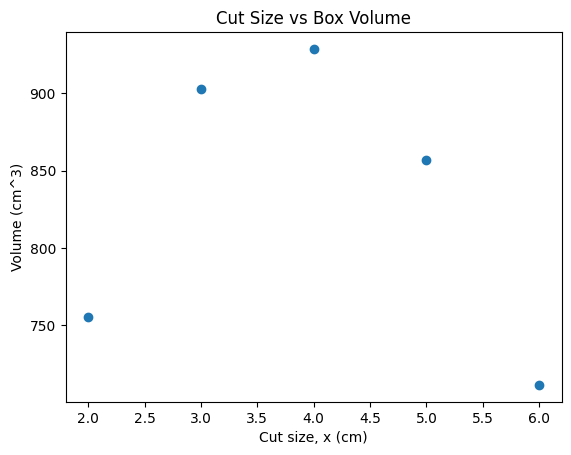

In [31]:
import matplotlib.pyplot as plt

plt.scatter(df['x'],df['volume'])
plt.xlabel('Cut size, x (cm)')
plt.ylabel('Volume (cm^3)')
plt.title('Cut Size vs Box Volume')

plt.show()

In [35]:
df.dtypes

,0
x,object
volume,object


In [37]:
df['x'] = pd.to_numeric(df['x'])
df['volume'] = pd.to_numeric(df['volume'])

In [38]:
coefficients = np.polyfit(df['x'],df['volume'],3)
coefficients

array([ 4.00000000e+00, -9.68000000e+01,  5.55390000e+02, -4.77917615e-12])

In [39]:
from sklearn.metrics import r2_score

x = df['x'].to_numpy()
y = df['volume'].to_numpy()

x

array([2, 3, 4, 5, 6])

In [41]:
coefficients = np.polyfit(x,y,3)
coefficients

array([ 4.00000000e+00, -9.68000000e+01,  5.55390000e+02, -4.77917615e-12])

In [43]:
y_fit = np.polyval(coefficients, x)
r2 = r2_score(y, y_fit)
r2

1.0

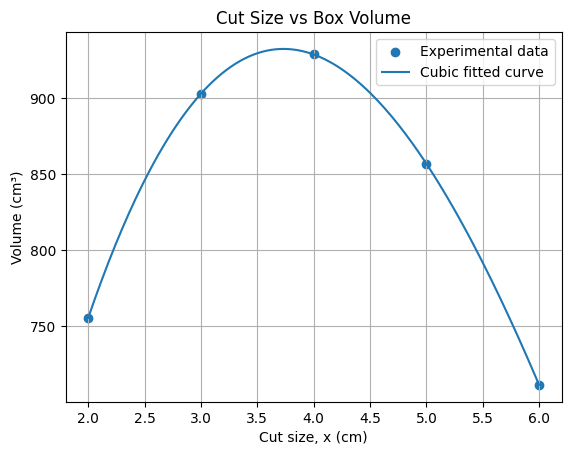

In [47]:
plt.scatter(x,y, label = 'Experimental data')

x_smooth = np.linspace(x.min(), x.max(), 200)
y_smooth = np.polyval(coefficients, x_smooth)

plt.plot(x_smooth,y_smooth, label = 'Cubic fitted curve')

plt.xlabel('Cut size, x (cm)')
plt.ylabel('Volume (cm³)')
plt.title('Cut Size vs Box Volume')
plt.legend()
plt.grid(True)

plt.show()

## Differentiation

The fitted cubic model is:

\[
V(x)=4x^3-96.8x^2+555.39x
\]

Differentiating with respect to \(x\):

\[
V'(x)=12x^2-193.6x+555.39
\]

For a possible maximum or minimum, we set the first derivative equal to zero:

\[
V'(x)=0
\]

Therefore,

\[
12x^2-193.6x+555.39=0
\]

In [48]:
critical_points = np.roots([12,-193.6,555.39])
critical_points

array([12.40124982,  3.73208351])

## Feasible Domain

The original sheet has dimensions:

\[
29.7 cm x 18.7 cm
\]

After cutting squares of side \(x\), the width of the base becomes:

\[
18.7-2x
\]

For the box to have a positive width:

\[
18.7-2x>0
\]

Therefore:

\[
x<9.35
\]

Thus, the feasible domain is:

\[
0<x<9.35
\]

Therefore, the feasible critical point is:

\[
x=3.7321 cm
\]

## Verification of Maximum

The second derivative is:

\[
V''(x)=24x-193.6
\]

At the feasible critical point \(x=3.7321\):

\[
V''(3.7321)<0
\]

Since the second derivative is negative, the function is concave downward at this point.

Therefore,

\[
x=3.7321 cm
\]

gives a maximum volume.

In [50]:
x_opt = 3.7321

max_volume = 4*x_opt**3 - 96.8 * x_opt**2 + 555.39*x_opt
max_volume

932.4166738206441

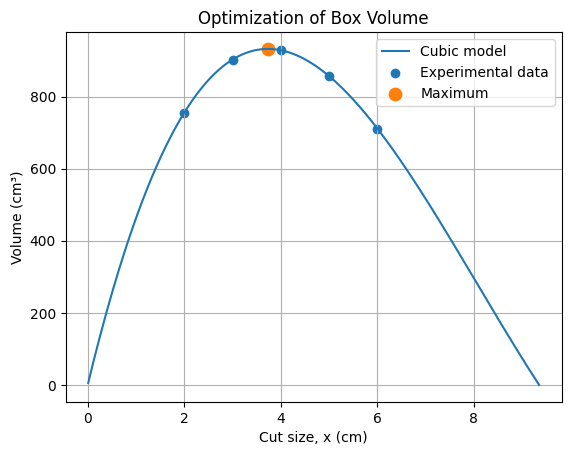

In [53]:
max_volume = np.polyval(coefficients, x_opt)

x_curve = np.linspace(0.01, 9.35, 300)

volume_curve = np.polyval(coefficients, x_curve)

plt.plot(x_curve, volume_curve, label="Cubic model")
plt.scatter(x, y, label="Experimental data")
plt.scatter(x_opt, max_volume, s=80, label="Maximum")

plt.xlabel("Cut size, x (cm)")
plt.ylabel("Volume (cm³)")
plt.title("Optimization of Box Volume")

plt.legend()
plt.grid(True)

plt.show()

## Conclusion

In this experiment, an open-top box was constructed from a rectangular sheet of paper of size 29.7 x 18.7, by cutting equal squares from the four corners. The relationship between the cut size and the resulting box volume was studied using experimentally collected data.

A cubic polynomial was fitted to the experimental data, giving the mathematical model

$$
V(x)=4x^3-96.8x^2+555.39x.
$$

The model was differentiated to determine the critical points. After considering the physical constraints of the sheet and applying the second derivative test, the optimal cut size was found to be approximately

$$
x=3.73 cm
$$

At this cut size, the maximum volume of the box is approximately

$$
V=933 cm^3
$$

Thus, the experiment demonstrates how a real-life physical problem can be represented using a mathematical model and optimized using derivatives.
